# DDoS Detection using Machine Learning - SDN Ready

Notebook này là bản rút gọn, sạch và phù hợp để đưa vào báo cáo đồ án,
đồng thời xuất mô hình theo đúng định dạng để Ryu/SDN controller sử dụng.
Mục tiêu là xây dựng mô hình học máy phát hiện lưu lượng `Benign` và các
nhóm tấn công DDoS trong bộ dữ liệu CICDDoS2019.

Nguyên tắc chính:

- Không đưa nhãn mục tiêu vào tập đặc trưng.
- Không fit scaler, imputer hoặc bộ lọc tương quan trên toàn bộ dữ liệu trước khi chia train/test.
- Chia dữ liệu bằng `stratify` để giữ phân bố lớp.
- Đánh giá bằng các chỉ số phù hợp với dữ liệu mất cân bằng: `Balanced Accuracy`, `Macro F1`, `Weighted F1`, báo cáo từng lớp và ma trận nhầm lẫn.
- Lưu best pipeline trực tiếp vào `saved_models/selected_model.pkl` để controller có thể gọi `predict_proba`.

## 1. Project Overview

In [1]:
from pathlib import Path
import pickle
import re
import sys
import time
import warnings

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:\source\CyRadar\VBoxShare\mlddos"),
    Path("/mnt/d/source/CyRadar/VBoxShare/mlddos"),
]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "backend" / "src").exists()),
    Path.cwd(),
)
BACKEND_SRC = PROJECT_ROOT / "backend" / "src"
if str(BACKEND_SRC) not in sys.path:
    sys.path.insert(0, str(BACKEND_SRC))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "saved_models"
for directory in (DATA_DIR, RESULTS_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 3
CV_MAX_PER_CLASS = 3000

warnings.filterwarnings("ignore", category=FutureWarning)
print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Project root: D:\source\CyRadar\VBoxShare\mlddos
Dataset directory: D:\source\CyRadar\VBoxShare\mlddos\data
Results directory: D:\source\CyRadar\VBoxShare\mlddos\results


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from IPython import get_ipython
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from xgboost import XGBClassifier

from ml_ddos.data_loader import KAGGLE_DATASET_SLUG, collect_file_paths, load_dataset
from ml_ddos.models import (
    CappedUnderSamplingStrategy,
    LEAKAGE_COLUMN_PATTERNS,
    TrafficFeaturePreprocessor,
)
from ml_ddos.preprocessor import TARGET_COL, harmonize_labels, remove_duplicates
from ml_ddos.sdn_ryu_detector import CICDDOS_FEATURE_COLUMNS

warnings.filterwarnings("ignore", category=ConvergenceWarning)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print("Dataset:", KAGGLE_DATASET_SLUG)

Dataset: dhoogla/cicddos2019


## 3. Load Dataset

In [3]:
train_paths, test_paths = collect_file_paths(str(DATA_DIR))
file_summary = pd.DataFrame(
    {
        "training_files": pd.Series([Path(path).name for path in train_paths]),
        "testing_files": pd.Series([Path(path).name for path in test_paths]),
    }
)
display(file_summary.head(20))

train_raw, test_raw = load_dataset(str(DATA_DIR))
print("Raw train shape:", train_raw.shape)
print("Raw test shape:", test_raw.shape)
display(train_raw.head())
print("Columns:")
print(list(train_raw.columns))

if TARGET_COL not in train_raw.columns or TARGET_COL not in test_raw.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in train/test data.")

[data_loader] Found 7 training files, 10 testing files.


,training_files,testing_files
0,LDAP-training.parquet,DNS-testing.parquet
1,MSSQL-training.parquet,LDAP-testing.parquet
2,NetBIOS-training.parquet,MSSQL-testing.parquet
3,Portmap-training.parquet,NTP-testing.parquet
4,Syn-training.parquet,NetBIOS-testing.parquet
5,UDP-training.parquet,SNMP-testing.parquet
6,UDPLag-training.parquet,Syn-testing.parquet
7,NaN,TFTP-testing.parquet
8,NaN,UDP-testing.parquet
9,NaN,UDPLag-testing.parquet


[data_loader] Dataset already present (17 files). Skipping download.
[data_loader] Found 7 training files, 10 testing files.
[data_loader] Common attack types: ['LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
[data_loader] Loading training data ...


Train files:   0%|          | 0/6 [00:00<?, ?it/s]

Train files:  50%|█████     | 3/6 [00:00<00:00, 26.28it/s]

...

Test files: 100%|██████████| 6/6 [00:00<00:00, 57.99it/s]

Test files: 100%|██████████| 6/6 [00:00<00:00, 55.60it/s]

[data_loader] Train shape: (120065, 78), Test shape: (38973, 78)
Raw train shape: (120065, 78)
Raw test shape: (38973, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'D

## 4. Data Cleaning

In [4]:
train_harmonized, test_harmonized = harmonize_labels(train_raw, test_raw)

cleaning_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows_before": len(train_harmonized),
            "duplicates_before": int(train_harmonized.duplicated().sum()),
        },
        {
            "split": "test",
            "rows_before": len(test_harmonized),
            "duplicates_before": int(test_harmonized.duplicated().sum()),
        },
    ]
)

train_clean = remove_duplicates(train_harmonized, "training source")
test_clean = remove_duplicates(test_harmonized, "testing source")
combined_df = pd.concat([train_clean, test_clean], ignore_index=True)
combined_duplicates = int(combined_df.duplicated().sum())
combined_df = combined_df.drop_duplicates().reset_index(drop=True)

numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
inf_count = int(np.isinf(combined_df[numeric_cols]).sum().sum()) if len(numeric_cols) else 0
missing_count = int(combined_df.isna().sum().sum())

cleaning_summary["rows_after_source_dedup"] = [len(train_clean), len(test_clean)]
display(cleaning_summary)
print("Combined shape after source dedup:", combined_df.shape)
print("Duplicate rows removed after combining sources:", combined_duplicates)
print("Total missing values:", missing_count)
print("Total inf/-inf values in numeric columns:", inf_count)

[preprocessor] Removing test-only labels (not in train): {'WebDDoS'}


[preprocessor] Labels harmonized. Train classes: ['Benign', 'LDAP Flood', 'MSSQL Flood', 'NetBIOS Flood', 'TCP SYN Flood', 'UDP Flood', 'UDP-Lag Flood']

[preprocessor] Removed 3,195 duplicate rows from training source.


[preprocessor] Removed 242 duplicate rows from testing source.


,split,rows_before,duplicates_before,rows_after_source_dedup
0,train,120065,3195,116870
1,test,38922,242,38680


Combined shape after source dedup: (151536, 78)
Duplicate rows removed after combining sources: 4014
Total missing values: 0
Total inf/-inf values in numeric columns: 0


## 5. Exploratory Data Analysis

,class,count,percent
0,Benign,51534,34.007761
1,TCP SYN Flood,47779,31.529801
2,UDP Flood,27525,18.164001
3,MSSQL Flood,12228,8.069370
4,UDP-Lag Flood,8915,5.883090
5,LDAP Flood,2722,1.796273
6,NetBIOS Flood,833,0.549704


,binary_class,count,percent
0,Attack,100002,65.992239
1,Benign,51534,34.007761


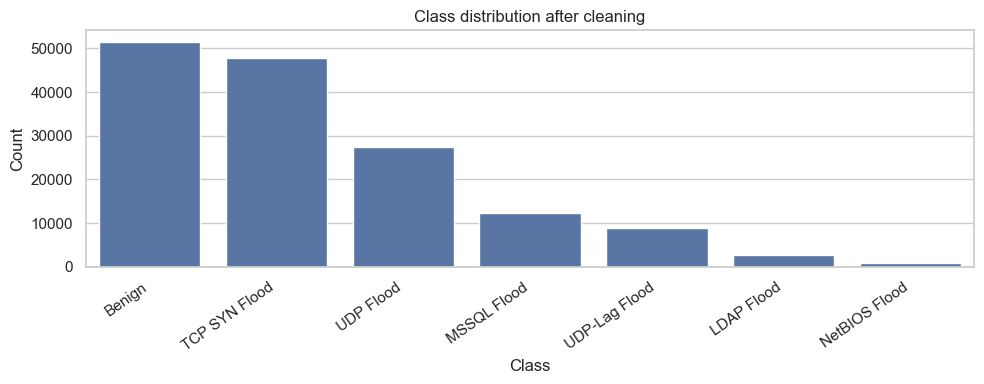

No missing values detected.


In [5]:
class_distribution = (
    combined_df[TARGET_COL]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["percent"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)
display(class_distribution)

binary_distribution = (
    combined_df[TARGET_COL]
    .map(lambda value: "Benign" if value == "Benign" else "Attack")
    .value_counts()
    .rename_axis("binary_class")
    .reset_index(name="count")
)
binary_distribution["percent"] = (
    binary_distribution["count"] / binary_distribution["count"].sum() * 100
)
display(binary_distribution)

plt.figure(figsize=(10, 4))
sns.barplot(data=class_distribution, x="class", y="count", color="#4c72b0")
plt.title("Class distribution after cleaning")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

missing_summary = (
    combined_df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
)
if missing_summary.empty:
    print("No missing values detected.")
else:
    display(missing_summary.rename("missing_count").to_frame().head(20))

,selected_numeric_feature
0,Fwd Header Length
1,Flow Bytes/s
2,Fwd Seg Size Min
3,Bwd Header Length
4,Fwd IAT Total
5,Flow Duration
6,Bwd IAT Total
7,Bwd IAT Max
8,Idle Max
9,Fwd IAT Max


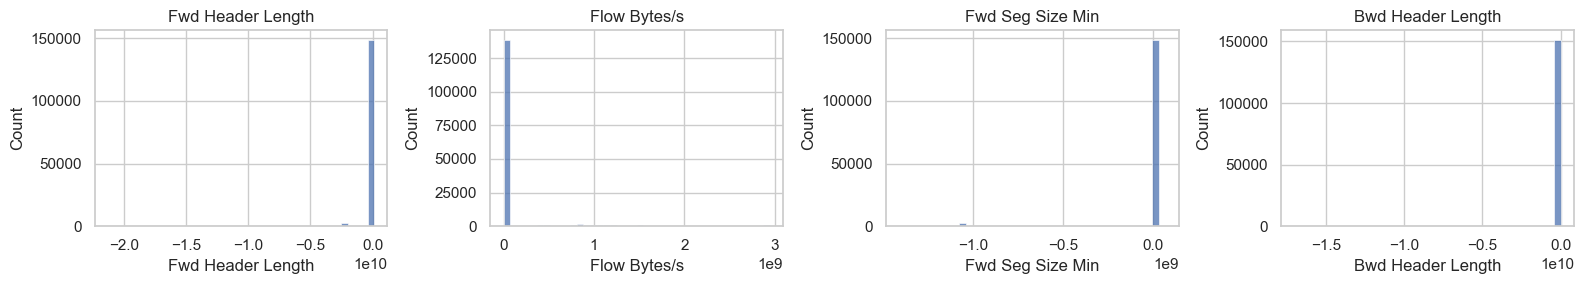

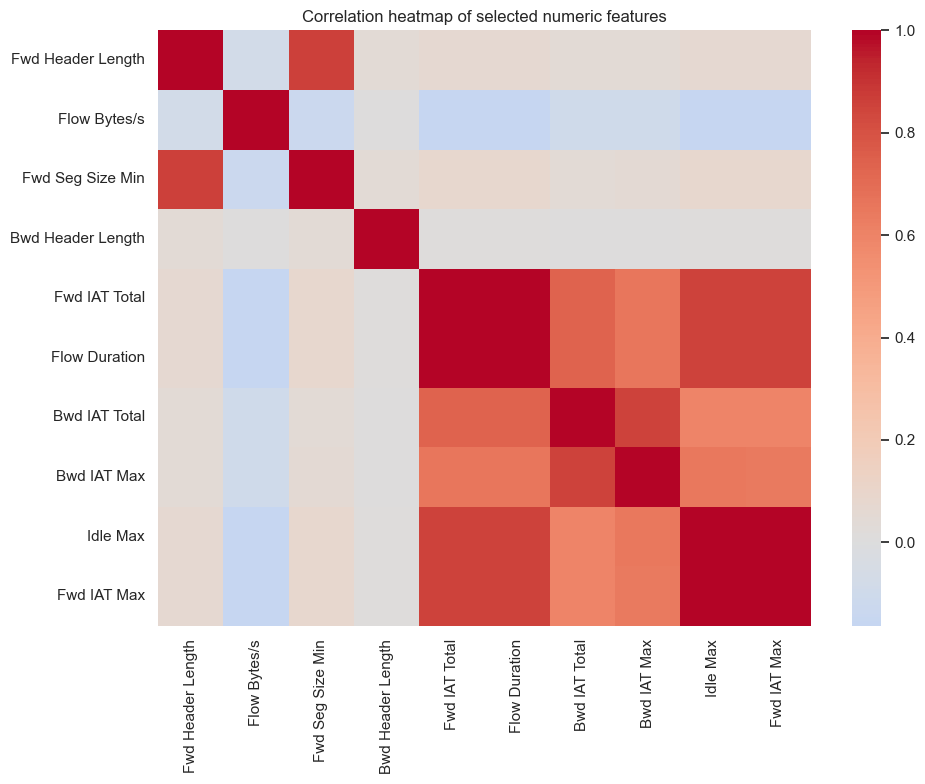

In [6]:
numeric_features = combined_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COL], errors="ignore")
if not numeric_features.empty:
    variance_top = numeric_features.var(numeric_only=True).sort_values(ascending=False).head(10).index.tolist()
    display(pd.DataFrame({"selected_numeric_feature": variance_top}))

    plot_cols = variance_top[:4]
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 3))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.histplot(combined_df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

    corr_cols = variance_top[:20]
    corr_matrix = (
        combined_df[corr_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(combined_df[corr_cols].median(numeric_only=True))
        .corr()
    )
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
    plt.title("Correlation heatmap of selected numeric features")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns found for EDA plots.")

## 6. Data Quality and Leakage Check

In [7]:
def find_leakage_like_columns(columns):
    found = []
    for col in columns:
        normalized = re.sub(r"[_\-]+", " ", str(col).strip().lower())
        if any(re.search(pattern, normalized) for pattern in LEAKAGE_COLUMN_PATTERNS):
            found.append(col)
    return found


leakage_like_columns = [
    col for col in find_leakage_like_columns(combined_df.columns)
    if col != TARGET_COL
]
constant_columns = [
    col for col in combined_df.columns
    if col != TARGET_COL and combined_df[col].nunique(dropna=False) <= 1
]
high_unique_columns = [
    {
        "feature": col,
        "unique_count": int(combined_df[col].nunique(dropna=False)),
        "unique_ratio": float(combined_df[col].nunique(dropna=False) / len(combined_df)),
    }
    for col in combined_df.columns
    if col != TARGET_COL and combined_df[col].nunique(dropna=False) / len(combined_df) > 0.5
]

leakage_check = pd.DataFrame(
    [
        {"check": "Target is not in feature matrix", "status": "checked before split"},
        {"check": "Duplicate rows removed before split", "status": f"{combined_duplicates} removed after combine"},
        {"check": "Leakage-like columns detected", "status": ", ".join(map(str, leakage_like_columns)) or "none"},
        {"check": "Constant columns detected", "status": str(len(constant_columns))},
        {"check": "Preprocessing fit scope", "status": "inside Pipeline, fit on train/CV fold only"},
    ]
)
display(leakage_check)
display(pd.DataFrame(high_unique_columns).head(20))

,check,status
0,Target is not in feature matrix,checked before split
1,Duplicate rows removed before split,4014 removed after combine
2,Leakage-like columns detected,none
3,Constant columns detected,12
4,Preprocessing fit scope,"inside Pipeline, fit on train/CV fold only"


,feature,unique_count,unique_ratio
0,Flow Duration,88123,0.581532
1,Flow Bytes/s,96036,0.633750
2,Flow Packets/s,90102,0.594591
3,Flow IAT Mean,89992,0.593865
4,Flow IAT Std,101931,0.672652
5,Flow IAT Max,82221,0.542584
6,Fwd IAT Total,76469,0.504626
7,Fwd IAT Mean,77288,0.510031
8,Fwd IAT Std,86278,0.569356
9,Fwd Packets/s,89115,0.588078


## 7. Preprocessing and Stratified Split

In [8]:
X_all = combined_df.drop(columns=[TARGET_COL])
y_text = combined_df[TARGET_COL].astype(str)

X_train, X_test, y_train_text, y_test_text = train_test_split(
    X_all,
    y_text,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_text,
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)
class_names = label_encoder.classes_.tolist()

label_mapping = pd.DataFrame(
    {"encoded_label": range(len(class_names)), "original_label": class_names}
)
display(label_mapping)

split_distribution = pd.DataFrame(
    {
        "original": y_text.value_counts().sort_index(),
        "train": y_train_text.value_counts().sort_index(),
        "test": y_test_text.value_counts().sort_index(),
    }
)
split_distribution["train_plus_test"] = split_distribution["train"] + split_distribution["test"]
split_distribution["integrity_ok"] = split_distribution["original"] == split_distribution["train_plus_test"]
display(split_distribution)

if not split_distribution["integrity_ok"].all():
    raise ValueError("Split integrity check failed: train + test counts do not match original counts.")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Target included in X:", TARGET_COL in X_train.columns)

,encoded_label,original_label
0,0,Benign
1,1,LDAP Flood
2,2,MSSQL Flood
3,3,NetBIOS Flood
4,4,TCP SYN Flood
5,5,UDP Flood
6,6,UDP-Lag Flood


,original,train,test,train_plus_test,integrity_ok
Label,,,,,
Benign,51534,41227,10307,51534,True
LDAP Flood,2722,2178,544,2722,True
MSSQL Flood,12228,9782,2446,12228,True
NetBIOS Flood,833,666,167,833,True
TCP SYN Flood,47779,38223,9556,47779,True
UDP Flood,27525,22020,5505,27525,True
UDP-Lag Flood,8915,7132,1783,8915,True


X_train: (121228, 77) X_test: (30308, 77)
Target included in X: False


## 8. Imbalance Handling

In [9]:
train_class_counts = pd.Series(y_train).value_counts().sort_index()
train_class_counts.index = [class_names[idx] for idx in train_class_counts.index]
test_class_counts = pd.Series(y_test).value_counts().sort_index()
test_class_counts.index = [class_names[idx] for idx in test_class_counts.index]

imbalance_table = pd.DataFrame(
    {
        "train_count": train_class_counts,
        "test_count": test_class_counts,
    }
)
imbalance_table["train_percent"] = imbalance_table["train_count"] / imbalance_table["train_count"].sum() * 100
imbalance_table["test_percent"] = imbalance_table["test_count"] / imbalance_table["test_count"].sum() * 100
display(imbalance_table)

minority_class_indices = [
    int(label)
    for label, count in pd.Series(y_train).value_counts().items()
    if count < 1000
]
if not minority_class_indices:
    minority_class_indices = [int(pd.Series(y_train).value_counts().idxmin())]
minority_class_names = [class_names[idx] for idx in minority_class_indices]
print("Minority classes used for recall tracking:", minority_class_names)

rare_warning = imbalance_table[imbalance_table["train_count"] < 100]
if not rare_warning.empty:
    print("Warning: Some classes have very few training samples and may be unstable:")
    display(rare_warning)

max_oversample_target = 2000
oversample_strategy = {
    int(label): int(min(max_oversample_target, max(count, count * 4)))
    for label, count in pd.Series(y_train).value_counts().sort_index().items()
    if count < max_oversample_target
}
print("RandomOverSampler strategy:", oversample_strategy)
print("RandomUnderSampler cap per majority class: 8000")

,train_count,test_count,train_percent,test_percent
Benign,41227,10307,34.007820,34.007523
LDAP Flood,2178,544,1.796615,1.794906
MSSQL Flood,9782,2446,8.069093,8.070476
NetBIOS Flood,666,167,0.549378,0.551010
TCP SYN Flood,38223,9556,31.529845,31.529629
UDP Flood,22020,5505,18.164121,18.163521
UDP-Lag Flood,7132,1783,5.883129,5.882935


Minority classes used for recall tracking: ['NetBIOS Flood']
RandomOverSampler strategy: {3: 2000}
RandomUnderSampler cap per majority class: 8000


## 9. Model Training

In [10]:
def make_preprocessor():
    return TrafficFeaturePreprocessor(correlation_threshold=0.90)


def make_pipeline(estimator, sampler=None):
    steps = [("preprocess", make_preprocessor())]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("model", estimator))
    return ImbPipeline(steps)


def random_forest(class_weight=None):
    return RandomForestClassifier(
        n_estimators=60,
        max_depth=6,
        min_samples_split=400,
        min_samples_leaf=180,
        max_features="sqrt",
        max_samples=0.50,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def extra_trees(class_weight=None):
    return ExtraTreesClassifier(
        n_estimators=70,
        max_depth=7,
        min_samples_split=450,
        min_samples_leaf=200,
        max_features="sqrt",
        max_samples=0.60,
        bootstrap=True,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def knn_model():
    return KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        metric="minkowski",
        n_jobs=-1,
    )


def xgboost_model():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        n_estimators=120,
        learning_rate=0.06,
        max_depth=2,
        min_child_weight=25,
        subsample=0.65,
        colsample_bytree=0.65,
        reg_alpha=0.5,
        reg_lambda=12.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def mlp_model():
    return MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        alpha=0.01,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.15,
        max_iter=300,
        random_state=RANDOM_STATE,
    )


candidate_specs = [
    {
        "model": "Random Forest",
        "method": "baseline",
        "pipeline": make_pipeline(random_forest()),
    },
    {
        "model": "Random Forest",
        "method": "class_weight",
        "pipeline": make_pipeline(random_forest(class_weight="balanced_subsample")),
    },
    {
        "model": "Extra Trees",
        "method": "baseline",
        "pipeline": make_pipeline(extra_trees()),
    },
    {
        "model": "KNN",
        "method": "RandomUnderSampler",
        "pipeline": make_pipeline(
            knn_model(),
            RandomUnderSampler(
                sampling_strategy=CappedUnderSamplingStrategy(cap=8000),
                random_state=RANDOM_STATE,
            ),
        ),
    },
    {
        "model": "XGBoost",
        "method": "baseline",
        "pipeline": make_pipeline(xgboost_model()),
    },
    {
        "model": "XGBoost",
        "method": "RandomUnderSampler",
        "pipeline": make_pipeline(
            xgboost_model(),
            RandomUnderSampler(
                sampling_strategy=CappedUnderSamplingStrategy(cap=8000),
                random_state=RANDOM_STATE,
            ),
        ),
    },
    {
        "model": "MLP Classifier",
        "method": "RandomOverSampler",
        "pipeline": make_pipeline(
            mlp_model(),
            RandomOverSampler(
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
            ),
        ),
    },
]

print("Candidate models:", len(candidate_specs))
display(pd.DataFrame([{k: v for k, v in spec.items() if k != "pipeline"} for spec in candidate_specs]))

Candidate models: 7


,model,method
0,Random Forest,baseline
1,Random Forest,class_weight
2,Extra Trees,baseline
3,KNN,RandomUnderSampler
4,XGBoost,baseline
5,XGBoost,RandomUnderSampler
6,MLP Classifier,RandomOverSampler


In [11]:
def make_cv_sample(X, y, max_per_class=CV_MAX_PER_CLASS):
    y_series = pd.Series(y, index=X.index)
    sampled_indices = []
    for label, label_indices in y_series.groupby(y_series).groups.items():
        label_indices = list(label_indices)
        if len(label_indices) > max_per_class:
            sampled = pd.Series(label_indices).sample(
                n=max_per_class,
                random_state=RANDOM_STATE,
            ).tolist()
        else:
            sampled = label_indices
        sampled_indices.extend(sampled)
    sampled_indices = pd.Index(sampled_indices)
    return X.loc[sampled_indices], y_series.loc[sampled_indices].to_numpy()


def minority_recall_score(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=minority_class_indices,
        average="macro",
        zero_division=0,
    )


def evaluate_candidate(spec, X_train, y_train, X_test, y_test):
    pipeline = clone(spec["pipeline"])
    start = time.time()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.time() - start

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    y_test_proba = None
    if hasattr(pipeline, "predict_proba"):
        y_test_proba = pipeline.predict_proba(X_test)
    report = classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    benign_index = int(np.where(label_encoder.classes_ == "Benign")[0][0])
    benign_mask = y_test == benign_index
    attack_mask = y_test != benign_index
    false_alarm_rate = (
        float(np.mean(y_test_pred[benign_mask] != benign_index))
        if benign_mask.any()
        else np.nan
    )
    attack_recall = (
        float(np.mean(y_test_pred[attack_mask] != benign_index))
        if attack_mask.any()
        else np.nan
    )
    roc_auc_macro = np.nan
    roc_auc_weighted = np.nan
    if y_test_proba is not None:
        try:
            roc_auc_macro = roc_auc_score(
                y_test,
                y_test_proba,
                multi_class="ovr",
                average="macro",
            )
            roc_auc_weighted = roc_auc_score(
                y_test,
                y_test_proba,
                multi_class="ovr",
                average="weighted",
            )
        except ValueError:
            pass

    row = {
        "Model": spec["model"],
        "Imbalance Method": spec["method"],
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "Macro F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Minority Class Recall": minority_recall_score(y_test, y_test_pred),
        "False Alarm Rate": false_alarm_rate,
        "Attack Recall": attack_recall,
        "ROC AUC Macro OvR": roc_auc_macro,
        "ROC AUC Weighted OvR": roc_auc_weighted,
        "Train Macro F1": f1_score(y_train, y_train_pred, average="macro", zero_division=0),
        "Test Macro F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Train/Test Gap": f1_score(y_train, y_train_pred, average="macro", zero_division=0)
        - f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Fit Seconds": fit_seconds,
    }

    for class_name in class_names:
        row[f"{class_name} Recall"] = report.get(class_name, {}).get("recall", 0.0)
        row[f"{class_name} F1"] = report.get(class_name, {}).get("f1-score", 0.0)

    tcp_syn_f1 = row.get("TCP SYN Flood F1", np.nan)
    udp_lag_f1 = row.get("UDP-Lag Flood F1", np.nan)
    notes = []
    if not np.isnan(tcp_syn_f1) and tcp_syn_f1 < 0.50:
        notes.append("TCP SYN F1 low")
    if not np.isnan(udp_lag_f1) and udp_lag_f1 < 0.20:
        notes.append("UDP-Lag F1 low")
    row["Notes"] = "; ".join(notes) if notes else "OK"
    return pipeline, row, y_test_pred, y_test_proba, report


X_cv, y_cv = make_cv_sample(X_train, y_train)
print("CV sample shape:", X_cv.shape)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "minority_recall": make_scorer(minority_recall_score),
}

fitted_models = {}
predictions = {}
probabilities = {}
reports = {}
comparison_rows = []

for spec in candidate_specs:
    print(f"Training {spec['model']} | {spec['method']} ...")
    cv_result = cross_validate(
        clone(spec["pipeline"]),
        X_cv,
        y_cv,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=1,
        error_score="raise",
    )
    fitted_pipeline, row, y_pred, y_proba, report = evaluate_candidate(
        spec,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    row["CV Macro F1 Mean"] = cv_result["test_macro_f1"].mean()
    row["CV Macro F1 Std"] = cv_result["test_macro_f1"].std()
    row["CV Weighted F1 Mean"] = cv_result["test_weighted_f1"].mean()
    row["CV Balanced Accuracy Mean"] = cv_result["test_balanced_accuracy"].mean()
    row["CV Minority Recall Mean"] = cv_result["test_minority_recall"].mean()

    model_key = f"{spec['model']} | {spec['method']}"
    fitted_models[model_key] = fitted_pipeline
    predictions[model_key] = y_pred
    probabilities[model_key] = y_proba
    reports[model_key] = report
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

guardrail_penalty = (
    comparison_df["Notes"].str.contains("TCP SYN F1 low", regex=False).astype(float) * 0.50
    + comparison_df["Notes"].str.contains("UDP-Lag F1 low", regex=False).astype(float) * 0.40
)
comparison_df["Selection Score"] = (
    comparison_df["Macro F1"]
    + 0.50 * comparison_df["Minority Class Recall"]
    + 0.25 * comparison_df["Balanced Accuracy"]
    - 0.25 * comparison_df["Train/Test Gap"].clip(lower=0)
    - guardrail_penalty
)

main_columns = [
    "Model",
    "Imbalance Method",
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
    "Minority Class Recall",
    "False Alarm Rate",
    "Attack Recall",
    "ROC AUC Macro OvR",
    "Train Macro F1",
    "Test Macro F1",
    "Train/Test Gap",
    "CV Macro F1 Mean",
    "CV Macro F1 Std",
    "TCP SYN Flood F1",
    "UDP-Lag Flood F1",
    "Notes",
    "Selection Score",
    "Fit Seconds",
]
display(comparison_df[main_columns].sort_values("Selection Score", ascending=False))

CV sample shape: (17844, 77)
Training Random Forest | baseline ...


Training Random Forest | class_weight ...


Training Extra Trees | baseline ...


Training KNN | RandomUnderSampler ...


Training XGBoost | baseline ...


Training XGBoost | RandomUnderSampler ...


Training MLP Classifier | RandomOverSampler ...


,Model,Imbalance Method,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Minority Class Recall,False Alarm Rate,Attack Recall,ROC AUC Macro OvR,Train Macro F1,Test Macro F1,Train/Test Gap,CV Macro F1 Mean,CV Macro F1 Std,TCP SYN Flood F1,UDP-Lag Flood F1,Notes,Selection Score,Fit Seconds
4,XGBoost,baseline,0.971592,0.905153,0.919874,0.970913,0.760479,0.001164,0.99620,0.994304,0.916563,0.919874,-0.003311,0.911910,0.002533,0.992941,0.842601,OK,1.526401,21.504452
5,XGBoost,RandomUnderSampler,0.967962,0.905630,0.914440,0.967427,0.766467,0.003396,0.99645,0.993909,0.911679,0.914440,-0.002761,0.910701,0.001669,0.989428,0.820183,OK,1.524081,11.937383
6,MLP Classifier,RandomOverSampler,0.963343,0.893006,0.906409,0.962077,0.784431,0.002231,0.99660,0.988822,0.904878,0.906409,-0.001531,0.873623,0.010326,0.982640,0.779955,OK,1.521876,163.693290
1,Random Forest,class_weight,0.956942,0.906774,0.876601,0.957286,0.784431,0.013874,0.99660,0.991465,0.868443,0.876601,-0.008158,0.885006,0.002802,0.989535,0.803957,OK,1.495510,6.985705
3,KNN,RandomUnderSampler,0.929062,0.891959,0.875670,0.933992,0.796407,0.002620,0.99810,0.969934,0.922507,0.875670,0.046837,0.885225,0.001607,0.933841,0.581316,OK,1.485154,4.429256
0,Random Forest,baseline,0.968259,0.885532,0.908124,0.967524,0.652695,0.001552,0.99535,0.991739,0.906988,0.908124,-0.001136,0.828353,0.037804,0.989481,0.821977,OK,1.455854,6.811255
2,Extra Trees,baseline,0.897387,0.638026,0.632793,0.867322,0.000000,0.015038,0.99600,0.980665,0.632024,0.632793,-0.000769,0.657257,0.020858,0.924480,0.000000,UDP-Lag F1 low,0.392299,5.603514


## 10. Evaluation of the Best Model

Best model: XGBoost | baseline
Model                      XGBoost
Imbalance Method          baseline
Accuracy                  0.971592
Balanced Accuracy         0.905153
Macro F1                  0.919874
Weighted F1               0.970913
Minority Class Recall     0.760479
False Alarm Rate          0.001164
Attack Recall               0.9962
ROC AUC Macro OvR         0.994304
Train Macro F1            0.916563
Test Macro F1             0.919874
Train/Test Gap           -0.003311
CV Macro F1 Mean           0.91191
CV Macro F1 Std           0.002533
TCP SYN Flood F1          0.992941
UDP-Lag Flood F1          0.842601
Notes                           OK
Selection Score           1.526401
Fit Seconds              21.504452


,precision,recall,f1-score,support
Benign,0.992672,0.998836,0.995744,10307.000000
LDAP Flood,0.860963,0.887868,0.874208,544.000000
MSSQL Flood,0.923557,0.968111,0.945309,2446.000000
NetBIOS Flood,0.927007,0.760479,0.835526,167.000000
TCP SYN Flood,0.999682,0.986291,0.992941,9556.000000
UDP Flood,0.924919,0.982380,0.952784,5505.000000
UDP-Lag Flood,0.957857,0.752103,0.842601,1783.000000
accuracy,0.971592,0.971592,0.971592,0.971592
macro avg,0.940951,0.905153,0.919874,30308.000000
weighted avg,0.972224,0.971592,0.970913,30308.000000


,Benign,LDAP Flood,MSSQL Flood,NetBIOS Flood,TCP SYN Flood,UDP Flood,UDP-Lag Flood
Benign,10295,0,0,8,0,0,4
LDAP Flood,4,483,57,0,0,0,0
MSSQL Flood,1,63,2368,0,0,14,0
NetBIOS Flood,7,1,30,127,0,2,0
TCP SYN Flood,58,0,12,0,9425,6,55
UDP Flood,1,0,93,2,1,5408,0
UDP-Lag Flood,5,14,4,0,2,417,1341


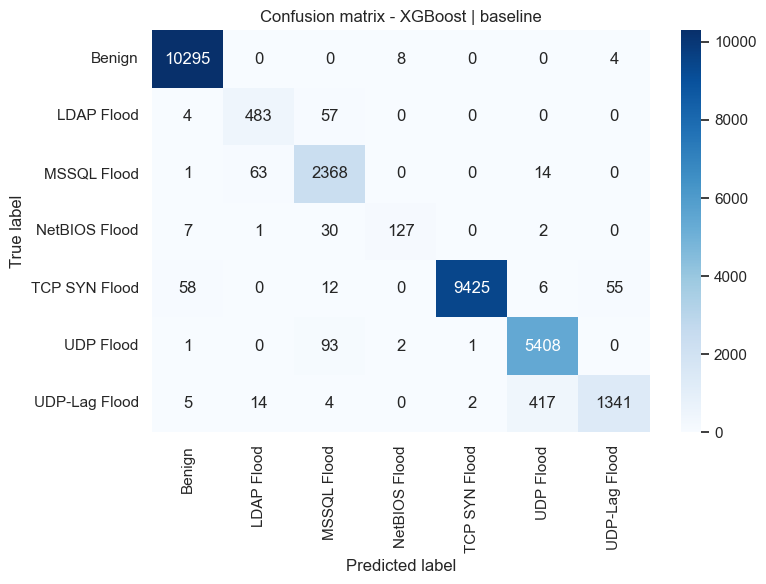

,predicted_count
Benign,10371
LDAP Flood,561
MSSQL Flood,2564
NetBIOS Flood,137
TCP SYN Flood,9428
UDP Flood,5847
UDP-Lag Flood,1400


In [12]:
best_row = comparison_df.sort_values("Selection Score", ascending=False).iloc[0]
best_model_key = f"{best_row['Model']} | {best_row['Imbalance Method']}"
best_model = fitted_models[best_model_key]
y_pred_best = predictions[best_model_key]
y_proba_best = probabilities[best_model_key]
best_report = reports[best_model_key]

print("Best model:", best_model_key)
print(best_row[main_columns].to_string())

report_df = pd.DataFrame(best_report).transpose()
display(report_df)

cm = confusion_matrix(y_test, y_pred_best, labels=list(range(len(class_names))))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix - {best_model_key}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

y_pred_counts = pd.Series(y_pred_best).value_counts().sort_index()
y_pred_counts.index = [class_names[idx] for idx in y_pred_counts.index]
display(y_pred_counts.rename("predicted_count").to_frame())

if best_row["Test Macro F1"] > 0.98:
    print("Warning: Test Macro F1 is very high. The dataset may be easy or hidden leakage may still exist.")
if best_row["Train/Test Gap"] > 0.05:
    print("Warning: Train/Test Macro F1 gap is large, indicating overfitting risk.")
if best_row["Notes"] != "OK":
    print("Warning:", best_row["Notes"])

## 11. Model Comparison

,Model,Imbalance Method,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Minority Class Recall,False Alarm Rate,Attack Recall,ROC AUC Macro OvR,Train Macro F1,Test Macro F1,Train/Test Gap,CV Macro F1 Mean,CV Macro F1 Std,TCP SYN Flood F1,UDP-Lag Flood F1,Notes,Selection Score,Fit Seconds
4,XGBoost,baseline,0.971592,0.905153,0.919874,0.970913,0.760479,0.001164,0.99620,0.994304,0.916563,0.919874,-0.003311,0.911910,0.002533,0.992941,0.842601,OK,1.526401,21.504452
5,XGBoost,RandomUnderSampler,0.967962,0.905630,0.914440,0.967427,0.766467,0.003396,0.99645,0.993909,0.911679,0.914440,-0.002761,0.910701,0.001669,0.989428,0.820183,OK,1.524081,11.937383
6,MLP Classifier,RandomOverSampler,0.963343,0.893006,0.906409,0.962077,0.784431,0.002231,0.99660,0.988822,0.904878,0.906409,-0.001531,0.873623,0.010326,0.982640,0.779955,OK,1.521876,163.693290
1,Random Forest,class_weight,0.956942,0.906774,0.876601,0.957286,0.784431,0.013874,0.99660,0.991465,0.868443,0.876601,-0.008158,0.885006,0.002802,0.989535,0.803957,OK,1.495510,6.985705
3,KNN,RandomUnderSampler,0.929062,0.891959,0.875670,0.933992,0.796407,0.002620,0.99810,0.969934,0.922507,0.875670,0.046837,0.885225,0.001607,0.933841,0.581316,OK,1.485154,4.429256
0,Random Forest,baseline,0.968259,0.885532,0.908124,0.967524,0.652695,0.001552,0.99535,0.991739,0.906988,0.908124,-0.001136,0.828353,0.037804,0.989481,0.821977,OK,1.455854,6.811255
2,Extra Trees,baseline,0.897387,0.638026,0.632793,0.867322,0.000000,0.015038,0.99600,0.980665,0.632024,0.632793,-0.000769,0.657257,0.020858,0.924480,0.000000,UDP-Lag F1 low,0.392299,5.603514


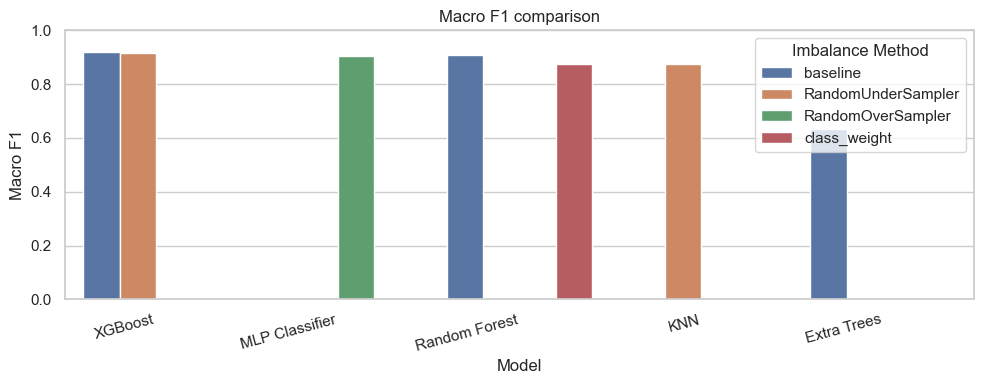

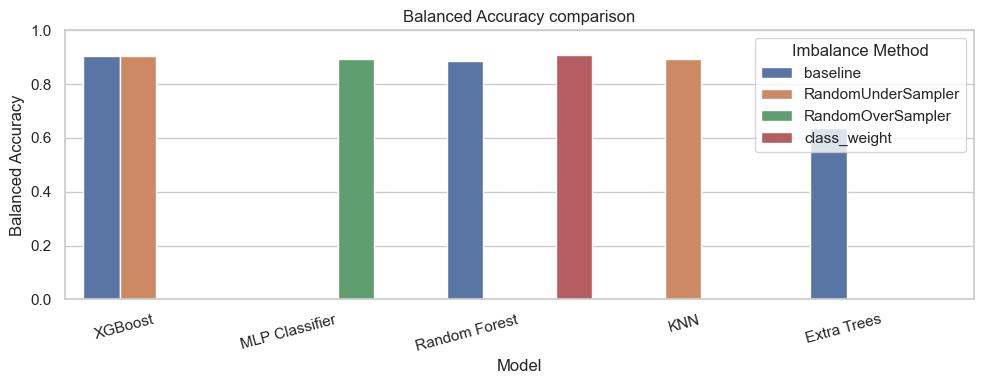

In [13]:
comparison_plot_df = comparison_df.sort_values("Selection Score", ascending=False).copy()
display(comparison_plot_df[main_columns])

plt.figure(figsize=(10, 4))
sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Macro F1",
    hue="Imbalance Method",
)
plt.title("Macro F1 comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Balanced Accuracy",
    hue="Imbalance Method",
)
plt.title("Balanced Accuracy comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 12. Per-model Classification Reports

Cell này tạo báo cáo phân loại chi tiết cho từng mô hình theo định dạng log,
thuận tiện để sao chép vào báo cáo đồ án.

In [14]:
from datetime import datetime

per_model_report_lines = []
per_model_report_dir = RESULTS_DIR / "per_model_reports"
per_model_report_dir.mkdir(parents=True, exist_ok=True)

for _, model_row in comparison_df.sort_values("Selection Score", ascending=False).iterrows():
    model_key = f"{model_row['Model']} | {model_row['Imbalance Method']}"
    y_pred_model = predictions[model_key]
    model_accuracy = accuracy_score(y_test, y_pred_model)
    false_alarm = float(model_row["False Alarm Rate"])
    attack_recall_value = float(model_row["Attack Recall"])
    roc_auc_value = float(model_row["ROC AUC Macro OvR"])
    report_text = classification_report(
        y_test,
        y_pred_model,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
    timestamp_accuracy = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
    timestamp_report = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]

    block = (
        f"{timestamp_accuracy} - INFO - Độ chính xác (Accuracy) trên tập test: {model_accuracy:.4f}\n"
        f"{timestamp_accuracy} - INFO - Tỉ lệ báo động giả (False Alarm Rate): {false_alarm:.4f}\n"
        f"{timestamp_accuracy} - INFO - Recall phát hiện tấn công tổng quát: {attack_recall_value:.4f}\n"
        f"{timestamp_accuracy} - INFO - ROC-AUC đa lớp macro OvR: {roc_auc_value:.4f}\n"
        f"{timestamp_report} - INFO - Báo cáo phân loại cho {model_key}:\n"
        f"{report_text}\n"
        + "=" * 90
        + "\n"
    )
    print(block)
    per_model_report_lines.append(block)

    safe_model_name = (
        model_key.lower()
        .replace(" | ", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )
    (per_model_report_dir / f"{safe_model_name}_classification_report.txt").write_text(
        block,
        encoding="utf-8",
    )

all_reports_path = RESULTS_DIR / "report_ready_per_model_classification_reports.txt"
all_reports_path.write_text("\n".join(per_model_report_lines), encoding="utf-8")
print("Saved all per-model reports:", all_reports_path)
print("Saved individual reports dir:", per_model_report_dir)

exact_one_rows = []
for model_key, report in reports.items():
    for label_name in class_names:
        label_report = report.get(label_name, {})
        for metric_name in ["precision", "recall", "f1-score"]:
            metric_value = float(label_report.get(metric_name, np.nan))
            if metric_value == 1.0:
                exact_one_rows.append(
                    {
                        "Model": model_key,
                        "Class": label_name,
                        "Metric": metric_name,
                        "Value": metric_value,
                        "Note": "Metric is exactly 1.0 on the current test split",
                    }
                )
exact_one_metric_audit = pd.DataFrame(exact_one_rows)
if exact_one_metric_audit.empty:
    print("No exact 1.0 precision/recall/f1-score values found in per-class reports.")
else:
    display(exact_one_metric_audit)
exact_one_metric_audit.to_csv(RESULTS_DIR / "report_ready_exact_one_metric_audit.csv", index=False)

2026-06-08 10:46:36.242 - INFO - Độ chính xác (Accuracy) trên tập test: 0.9716
2026-06-08 10:46:36.242 - INFO - Tỉ lệ báo động giả (False Alarm Rate): 0.0012
2026-06-08 10:46:36.242 - INFO - Recall phát hiện tấn công tổng quát: 0.9962
2026-06-08 10:46:36.242 - INFO - ROC-AUC đa lớp macro OvR: 0.9943
2026-06-08 10:46:36.242 - INFO - Báo cáo phân loại cho XGBoost | baseline:
               precision    recall  f1-score   support

       Benign     0.9927    0.9988    0.9957     10307
   LDAP Flood     0.8610    0.8879    0.8742       544
  MSSQL Flood     0.9236    0.9681    0.9453      2446
NetBIOS Flood     0.9270    0.7605    0.8355       167
TCP SYN Flood     0.9997    0.9863    0.9929      9556
    UDP Flood     0.9249    0.9824    0.9528      5505
UDP-Lag Flood     0.9579    0.7521    0.8426      1783

     accuracy                         0.9716     30308
    macro avg     0.9410    0.9052    0.9199     30308
 weighted avg     0.9722    0.9716    0.9709     30308


2026-06-08 10:4

## 13. Expected Results Coverage Check

Cell này kiểm tra các kết quả dự kiến trong báo cáo so với phạm vi dữ liệu
và code thực tế. Những lớp tấn công không có trong dataset hiện tại sẽ
không được tuyên bố là đã phân loại trong kết quả thực nghiệm.

In [15]:
expected_attack_labels = [
    "UDP Flood",
    "ICMP Flood",
    "TCP SYN Flood",
    "Ping of Death",
    "HTTP Flood",
    "LDAP Flood",
    "MSSQL Flood",
    "NetBIOS Flood",
    "UDP-Lag Flood",
]
observed_labels = set(class_names)
expected_coverage_df = pd.DataFrame(
    [
        {
            "Kết quả dự kiến": "Xây dựng mô hình phát hiện DDoS bằng học máy",
            "Trạng thái trong code": "Đã có",
            "Bằng chứng": "Có pipeline huấn luyện, so sánh model và selected_model.pkl",
        },
        {
            "Kết quả dự kiến": "Kiểm soát tỉ lệ báo động giả",
            "Trạng thái trong code": "Đã bổ sung",
            "Bằng chứng": "False Alarm Rate được tính cho từng model",
        },
        {
            "Kết quả dự kiến": "Phân loại các dạng DDoS có trong dataset",
            "Trạng thái trong code": "Đã có trong phạm vi dataset",
            "Bằng chứng": ", ".join(class_names),
        },
        {
            "Kết quả dự kiến": "Trích xuất đặc trưng từ dữ liệu thô",
            "Trạng thái trong code": "Một phần",
            "Bằng chứng": "Dataset hiện dùng flow-level features đã trích xuất sẵn; SDN demo chuyển flow stats thành vector đặc trưng",
        },
        {
            "Kết quả dự kiến": "Trực quan hóa phân bố, confusion matrix, ROC",
            "Trạng thái trong code": "Đã bổ sung",
            "Bằng chứng": "report_figures chứa biểu đồ phân bố, so sánh model, confusion matrix và ROC",
        },
    ]
)
display(expected_coverage_df)

attack_label_coverage_df = pd.DataFrame(
    [
        {
            "Dạng tấn công trong mô tả dự kiến": label,
            "Có trong dataset/code hiện tại": label in observed_labels,
            "Ghi chú": (
                "Được đánh giá trong classification report"
                if label in observed_labels
                else "Không có nhãn trong dataset hiện tại, không nên ghi là đã phân loại"
            ),
        }
        for label in expected_attack_labels
    ]
)
display(attack_label_coverage_df)

expected_coverage_df.to_csv(RESULTS_DIR / "report_ready_expected_results_coverage.csv", index=False)
attack_label_coverage_df.to_csv(RESULTS_DIR / "report_ready_attack_label_coverage.csv", index=False)

,Kết quả dự kiến,Trạng thái trong code,Bằng chứng
0,Xây dựng mô hình phát hiện DDoS bằng học máy,Đã có,"Có pipeline huấn luyện, so sánh model và selec..."
1,Kiểm soát tỉ lệ báo động giả,Đã bổ sung,False Alarm Rate được tính cho từng model
2,Phân loại các dạng DDoS có trong dataset,Đã có trong phạm vi dataset,"Benign, LDAP Flood, MSSQL Flood, NetBIOS Flood..."
3,Trích xuất đặc trưng từ dữ liệu thô,Một phần,Dataset hiện dùng flow-level features đã trích...
4,"Trực quan hóa phân bố, confusion matrix, ROC",Đã bổ sung,"report_figures chứa biểu đồ phân bố, so sánh m..."


,Dạng tấn công trong mô tả dự kiến,Có trong dataset/code hiện tại,Ghi chú
0,UDP Flood,True,Được đánh giá trong classification report
1,ICMP Flood,False,"Không có nhãn trong dataset hiện tại, không nê..."
2,TCP SYN Flood,True,Được đánh giá trong classification report
3,Ping of Death,False,"Không có nhãn trong dataset hiện tại, không nê..."
4,HTTP Flood,False,"Không có nhãn trong dataset hiện tại, không nê..."
5,LDAP Flood,True,Được đánh giá trong classification report
6,MSSQL Flood,True,Được đánh giá trong classification report
7,NetBIOS Flood,True,Được đánh giá trong classification report
8,UDP-Lag Flood,True,Được đánh giá trong classification report


## 14. Save Results

In [16]:
comparison_path = RESULTS_DIR / "report_ready_model_comparison.csv"
report_path = RESULTS_DIR / "report_ready_classification_report.csv"
cm_path = RESULTS_DIR / "report_ready_confusion_matrix.csv"
summary_path = RESULTS_DIR / "report_ready_final_summary.csv"
model_path = MODELS_DIR / "report_ready_best_model.pkl"
selected_model_path = MODELS_DIR / "selected_model.pkl"
metadata_path = RESULTS_DIR / "report_ready_selected_model_metadata.csv"

comparison_df.to_csv(comparison_path, index=False)
report_df.to_csv(report_path)
cm_df.to_csv(cm_path)

final_summary = pd.DataFrame(
    [
        {
            "total_rows": len(combined_df),
            "total_features_before_preprocessing": X_all.shape[1],
            "duplicates_removed_after_combine": combined_duplicates,
            "missing_values": missing_count,
            "inf_values": inf_count,
            "best_model": best_model_key,
            "accuracy": best_row["Accuracy"],
            "balanced_accuracy": best_row["Balanced Accuracy"],
            "macro_f1": best_row["Macro F1"],
            "weighted_f1": best_row["Weighted F1"],
            "minority_recall": best_row["Minority Class Recall"],
            "false_alarm_rate": best_row["False Alarm Rate"],
            "attack_recall": best_row["Attack Recall"],
            "roc_auc_macro_ovr": best_row["ROC AUC Macro OvR"],
            "train_test_gap": best_row["Train/Test Gap"],
            "cv_macro_f1_mean": best_row["CV Macro F1 Mean"],
            "cv_macro_f1_std": best_row["CV Macro F1 Std"],
            "notes": best_row["Notes"],
        }
    ]
)
final_summary.to_csv(summary_path, index=False)
display(final_summary)

# Ryu/SDN controller expects the pickle object itself to expose
# predict_proba(features). Therefore selected_model.pkl stores the
# fitted Pipeline directly, not a metadata dictionary.
with open(model_path, "wb") as file:
    pickle.dump(best_model, file)
with open(selected_model_path, "wb") as file:
    pickle.dump(best_model, file)

selected_metadata = pd.DataFrame(
    [
        {
            "selected_model_file": str(selected_model_path),
            "best_model": best_model_key,
            "class_names": "|".join(class_names),
            "accuracy": best_row["Accuracy"],
            "balanced_accuracy": best_row["Balanced Accuracy"],
            "macro_f1": best_row["Macro F1"],
            "weighted_f1": best_row["Weighted F1"],
            "minority_recall": best_row["Minority Class Recall"],
            "false_alarm_rate": best_row["False Alarm Rate"],
            "attack_recall": best_row["Attack Recall"],
            "roc_auc_macro_ovr": best_row["ROC AUC Macro OvR"],
            "cv_macro_f1_mean": best_row["CV Macro F1 Mean"],
            "cv_macro_f1_std": best_row["CV Macro F1 Std"],
        }
    ]
)
selected_metadata.to_csv(metadata_path, index=False)

print("Saved comparison:", comparison_path)
print("Saved classification report:", report_path)
print("Saved confusion matrix:", cm_path)
print("Saved summary:", summary_path)
print("Saved best model:", model_path)
print("Saved SDN selected model:", selected_model_path)
print("Saved selected model metadata:", metadata_path)

,total_rows,total_features_before_preprocessing,duplicates_removed_after_combine,missing_values,inf_values,best_model,accuracy,balanced_accuracy,macro_f1,weighted_f1,minority_recall,false_alarm_rate,attack_recall,roc_auc_macro_ovr,train_test_gap,cv_macro_f1_mean,cv_macro_f1_std,notes
0,151536,77,4014,0,0,XGBoost | baseline,0.971592,0.905153,0.919874,0.970913,0.760479,0.001164,0.9962,0.994304,-0.003311,0.91191,0.002533,OK


Saved comparison: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_model_comparison.csv
Saved classification report: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_classification_report.csv
Saved confusion matrix: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_confusion_matrix.csv
Saved summary: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_final_summary.csv
Saved best model: D:\source\CyRadar\VBoxShare\mlddos\saved_models\report_ready_best_model.pkl
Saved SDN selected model: D:\source\CyRadar\VBoxShare\mlddos\saved_models\selected_model.pkl
Saved selected model metadata: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_selected_model_metadata.csv


## 15. SDN Controller Compatibility Check

In [17]:
with open(selected_model_path, "rb") as file:
    sdn_model = pickle.load(file)

sdn_sample = pd.DataFrame([{column: 0.0 for column in CICDDOS_FEATURE_COLUMNS}])
sdn_sample["Protocol"] = 6
sdn_sample["Flow Duration"] = 1_000_000
sdn_sample["Total Fwd Packets"] = 10
sdn_sample["Fwd Packets Length Total"] = 600
sdn_sample["Flow Packets/s"] = 10
sdn_sample["Flow Bytes/s"] = 600

proba = sdn_model.predict_proba(sdn_sample)[0]
pred_index = int(np.argmax(proba))
sdn_check = pd.DataFrame(
    [
        {
            "selected_model_path": str(selected_model_path),
            "predict_proba_ok": True,
            "predicted_index": pred_index,
            "predicted_label": class_names[pred_index],
            "confidence": float(proba[pred_index]),
            "input_feature_count": sdn_sample.shape[1],
        }
    ]
)
display(sdn_check)

,selected_model_path,predict_proba_ok,predicted_index,predicted_label,confidence,input_feature_count
0,D:\source\CyRadar\VBoxShare\mlddos\saved_model...,True,0,Benign,0.687625,77


## 16. Report Figures

Cell này sinh các biểu đồ chính dùng để chèn vào báo cáo tốt nghiệp.
Tất cả biểu đồ được tạo từ dữ liệu và kết quả thực nghiệm thật trong notebook,
đồng thời được lưu thành ảnh PNG để có thể chèn trực tiếp vào Word.

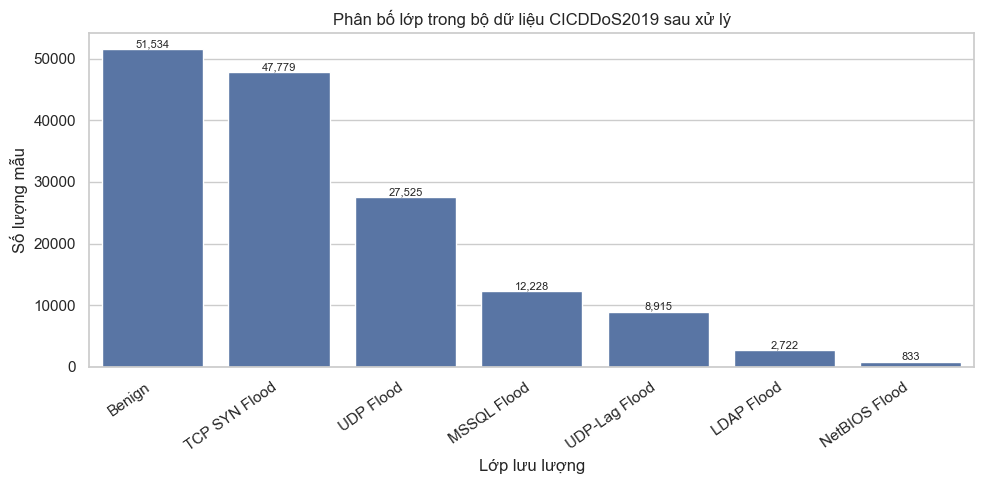

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\hinh_4_1_phan_bo_lop.png


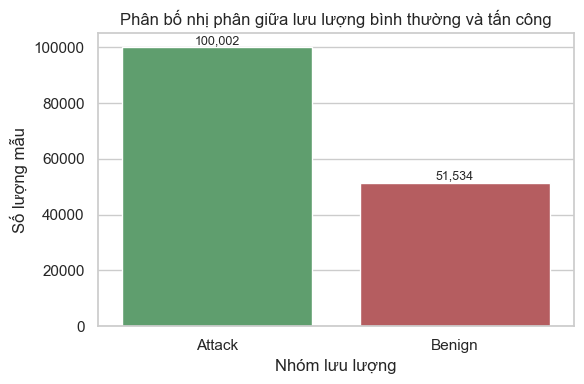

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\phan_bo_benign_attack.png


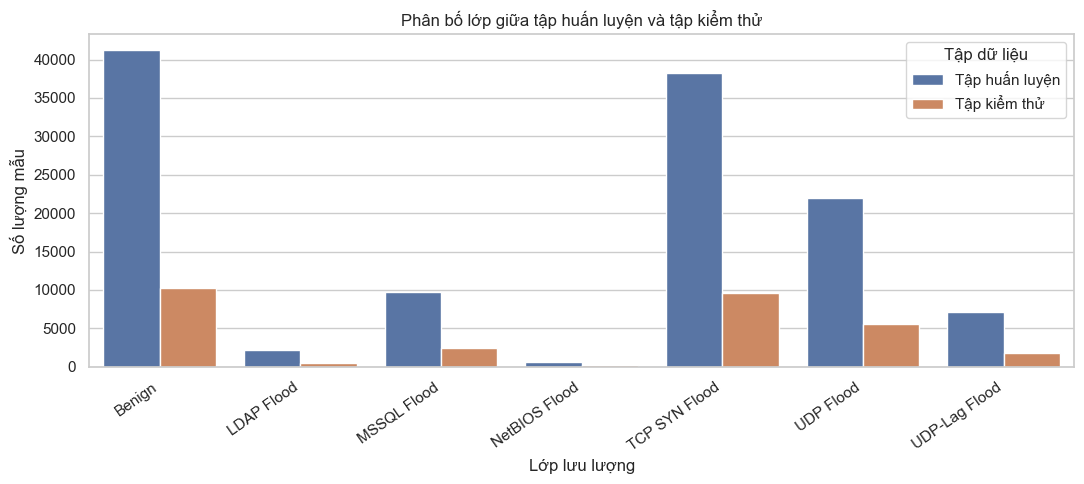

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\phan_bo_train_test.png


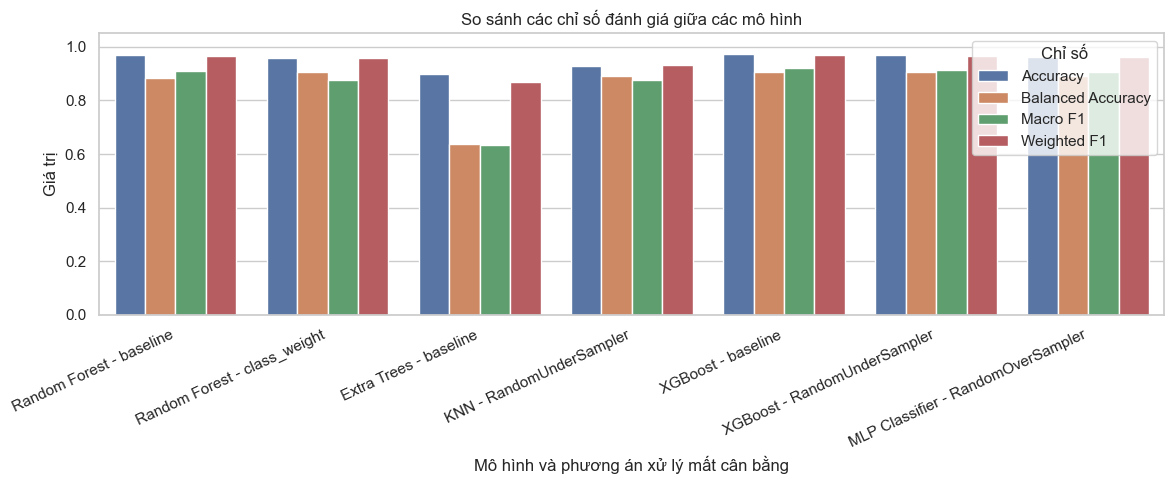

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\so_sanh_chi_so_mo_hinh.png


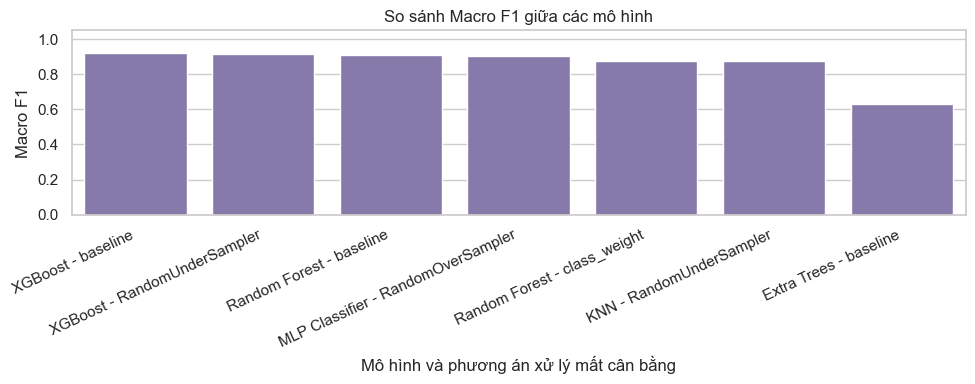

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\so_sanh_macro_f1.png


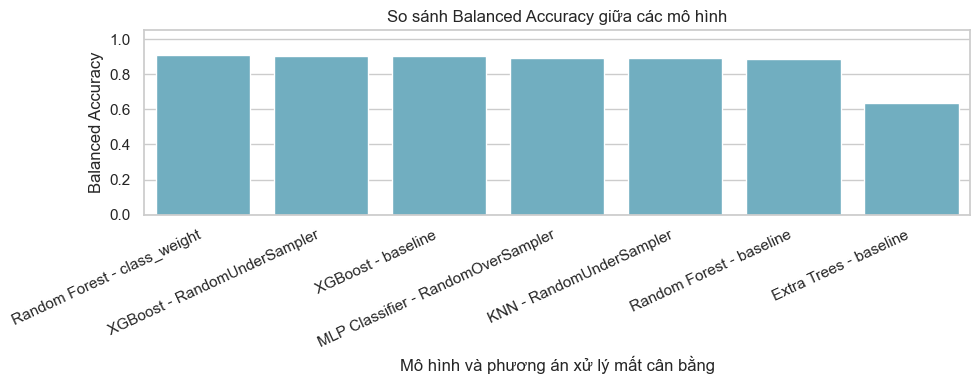

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\so_sanh_balanced_accuracy.png


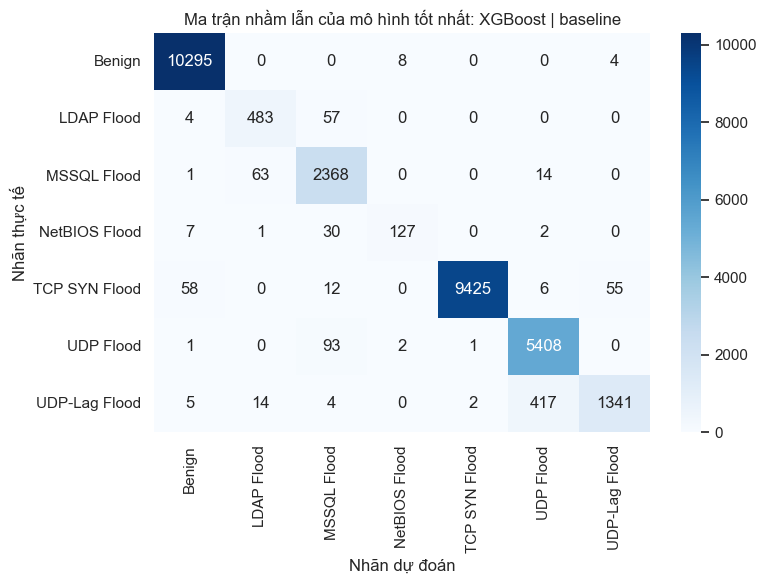

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\ma_tran_nham_lan_best_model.png


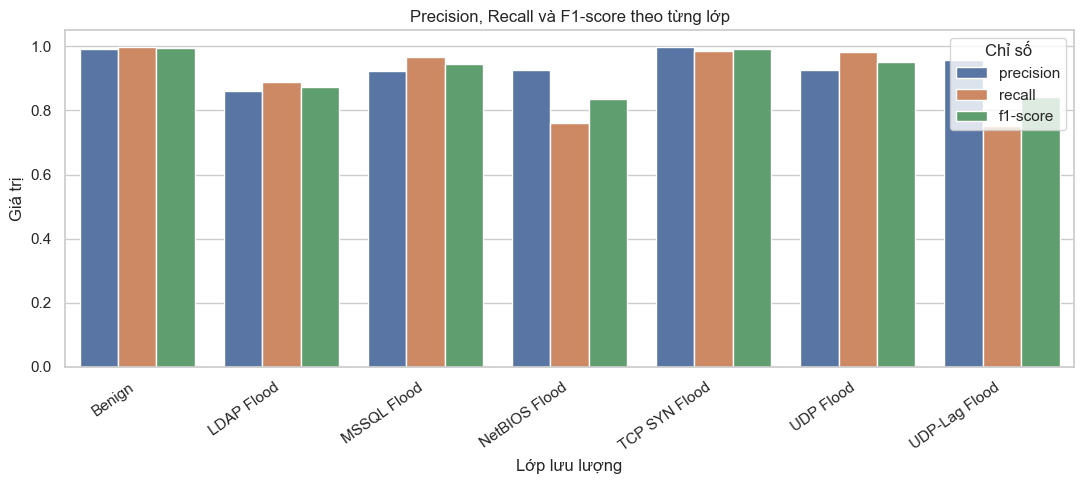

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\classification_report_theo_lop.png


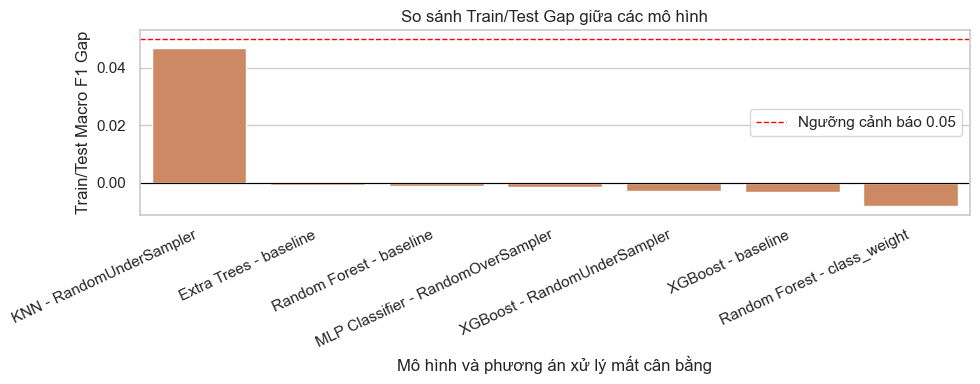

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\train_test_gap.png


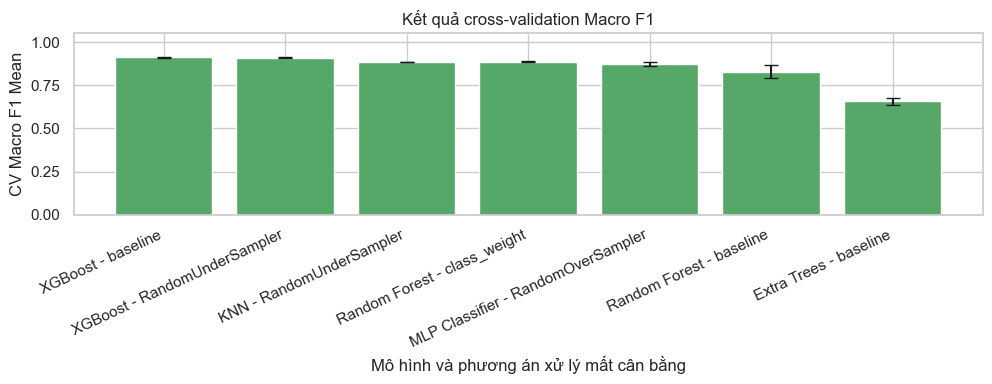

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\cross_validation_macro_f1.png


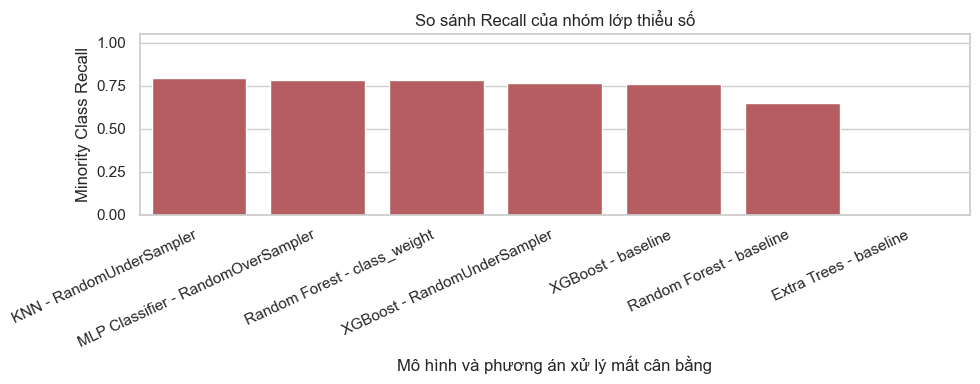

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\minority_recall.png


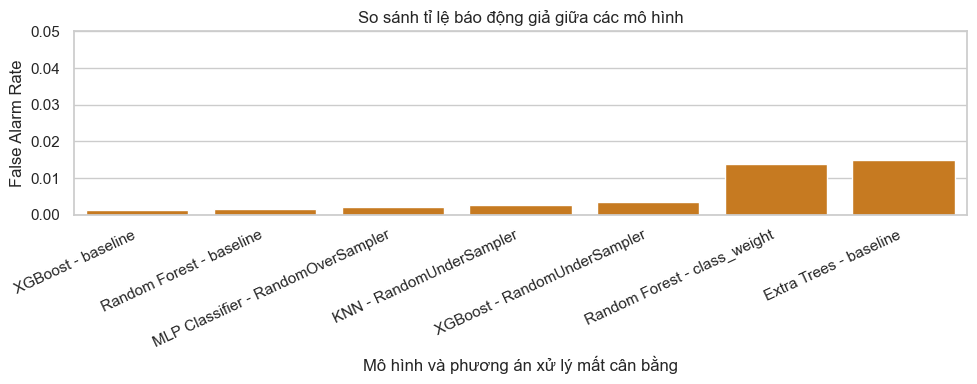

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\false_alarm_rate.png


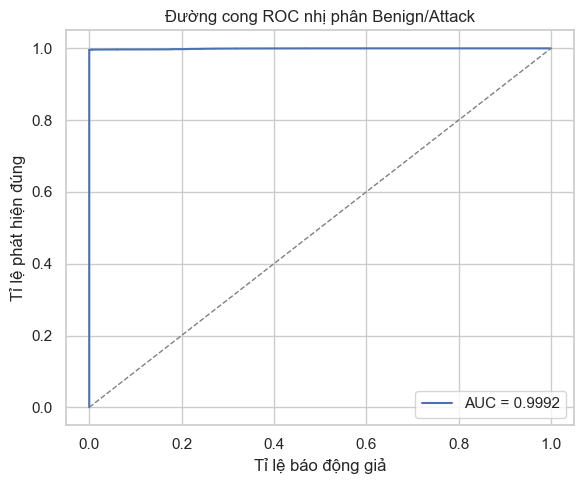

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\roc_binary_benign_attack.png


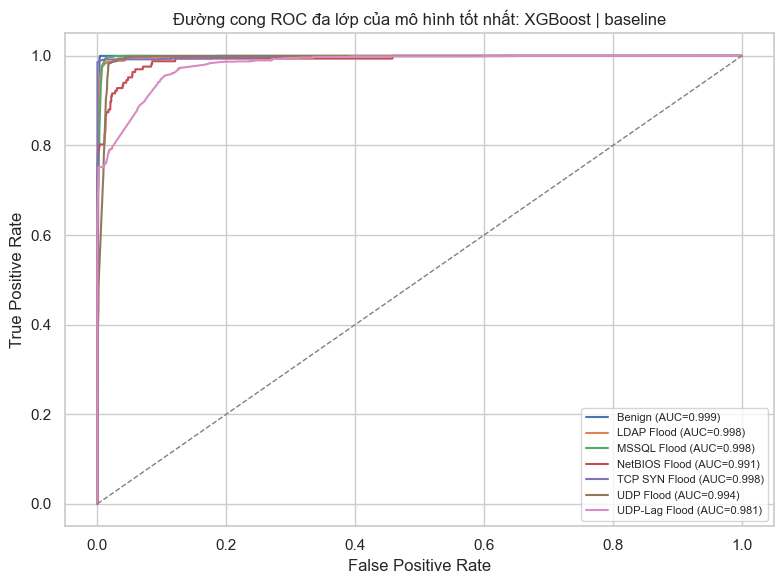

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\roc_multiclass_best_model.png


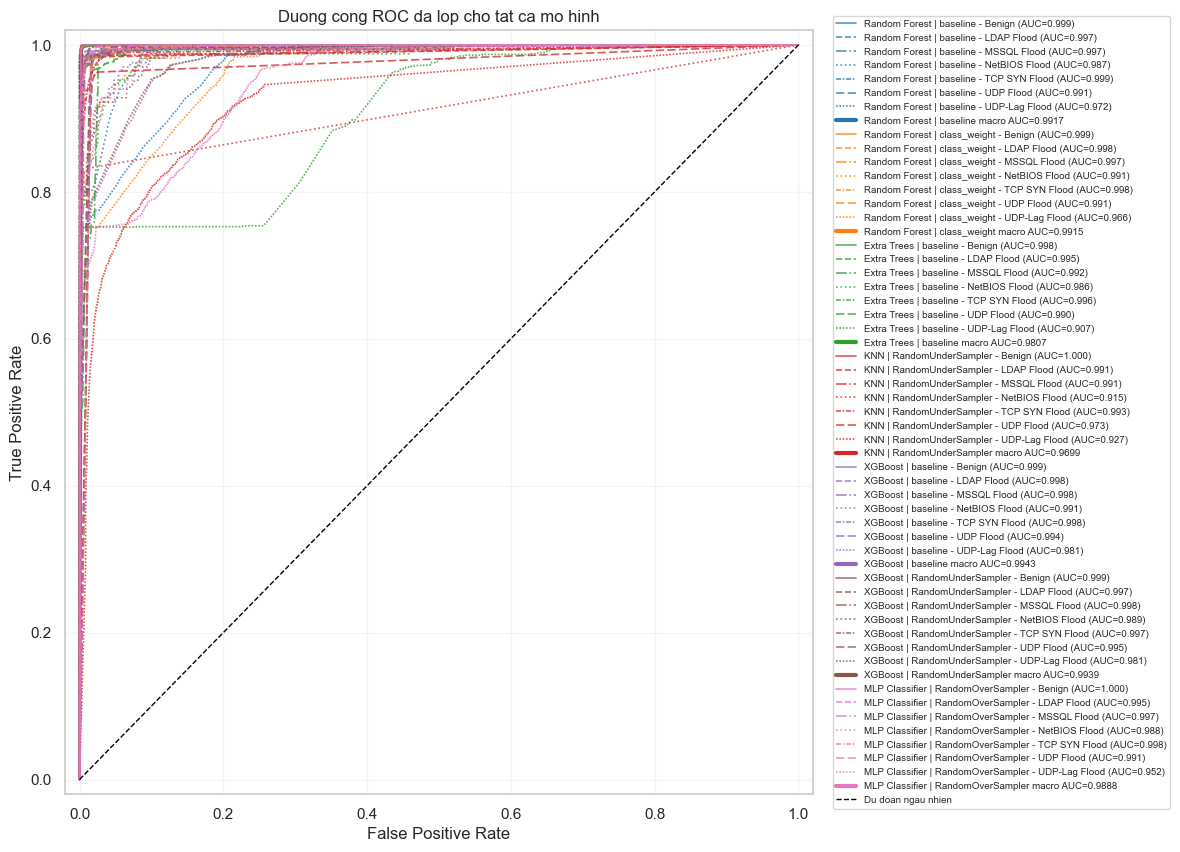

Saved: D:\source\CyRadar\VBoxShare\mlddos\results\report_figures\roc_all_models_multiclass.png


,Tên hình,File ảnh
0,Hình 4.1. Phân bố lớp trong bộ dữ liệu CICDDoS...,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
1,Phân bố nhị phân giữa Benign và Attack,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
2,Phân bố lớp giữa tập huấn luyện và tập kiểm thử,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
3,So sánh các chỉ số đánh giá giữa các mô hình,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
4,So sánh Macro F1 giữa các mô hình,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
5,So sánh Balanced Accuracy giữa các mô hình,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
6,Ma trận nhầm lẫn của mô hình tốt nhất,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
7,"Precision, Recall và F1-score theo từng lớp",D:\source\CyRadar\VBoxShare\mlddos\results\rep...
8,So sánh Train/Test Gap giữa các mô hình,D:\source\CyRadar\VBoxShare\mlddos\results\rep...
9,Kết quả cross-validation Macro F1,D:\source\CyRadar\VBoxShare\mlddos\results\rep...


In [18]:
REPORT_FIGURES_DIR = RESULTS_DIR / "report_figures"
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_report_figure(filename: str) -> Path:
    path = REPORT_FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
    return path


saved_figures = []

# Hình 4.1: Phân bố lớp trong bộ dữ liệu sau xử lý.
plt.figure(figsize=(10, 5))
class_plot_df = class_distribution.copy()
sns.barplot(data=class_plot_df, x="class", y="count", color="#4C72B0")
plt.title("Phân bố lớp trong bộ dữ liệu CICDDoS2019 sau xử lý")
plt.xlabel("Lớp lưu lượng")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=35, ha="right")
for index, row in class_plot_df.iterrows():
    plt.text(index, row["count"], f"{int(row['count']):,}", ha="center", va="bottom", fontsize=8)
saved_figures.append(save_report_figure("hinh_4_1_phan_bo_lop.png"))

# Phân bố nhị phân Benign/Attack.
plt.figure(figsize=(6, 4))
binary_plot_df = binary_distribution.copy()
sns.barplot(data=binary_plot_df, x="binary_class", y="count", palette=["#55A868", "#C44E52"])
plt.title("Phân bố nhị phân giữa lưu lượng bình thường và tấn công")
plt.xlabel("Nhóm lưu lượng")
plt.ylabel("Số lượng mẫu")
for index, row in binary_plot_df.iterrows():
    plt.text(index, row["count"], f"{int(row['count']):,}", ha="center", va="bottom", fontsize=9)
saved_figures.append(save_report_figure("phan_bo_benign_attack.png"))

# Phân bố lớp giữa tập huấn luyện và tập kiểm thử.
split_reset_df = split_distribution[["train", "test"]].reset_index()
split_reset_df = split_reset_df.rename(columns={split_reset_df.columns[0]: "class"})
split_plot_df = split_reset_df.melt(
    id_vars="class",
    var_name="Tập dữ liệu",
    value_name="Số lượng mẫu",
)
split_plot_df["Tập dữ liệu"] = split_plot_df["Tập dữ liệu"].map(
    {"train": "Tập huấn luyện", "test": "Tập kiểm thử"}
)
plt.figure(figsize=(11, 5))
sns.barplot(data=split_plot_df, x="class", y="Số lượng mẫu", hue="Tập dữ liệu")
plt.title("Phân bố lớp giữa tập huấn luyện và tập kiểm thử")
plt.xlabel("Lớp lưu lượng")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=35, ha="right")
saved_figures.append(save_report_figure("phan_bo_train_test.png"))

# So sánh các metric chính giữa các mô hình.
comparison_for_plot = comparison_df.copy()
comparison_for_plot["Mô hình"] = (
    comparison_for_plot["Model"] + " - " + comparison_for_plot["Imbalance Method"]
)
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]
metrics_plot_df = comparison_for_plot.melt(
    id_vars="Mô hình",
    value_vars=metrics_to_plot,
    var_name="Chỉ số",
    value_name="Giá trị",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=metrics_plot_df, x="Mô hình", y="Giá trị", hue="Chỉ số")
plt.title("So sánh các chỉ số đánh giá giữa các mô hình")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("Giá trị")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("so_sanh_chi_so_mo_hinh.png"))

# So sánh Macro F1 giữa các mô hình.
plt.figure(figsize=(10, 4))
macro_plot_df = comparison_for_plot.sort_values("Macro F1", ascending=False)
sns.barplot(data=macro_plot_df, x="Mô hình", y="Macro F1", color="#8172B2")
plt.title("So sánh Macro F1 giữa các mô hình")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("so_sanh_macro_f1.png"))

# So sánh Balanced Accuracy giữa các mô hình.
plt.figure(figsize=(10, 4))
balanced_plot_df = comparison_for_plot.sort_values("Balanced Accuracy", ascending=False)
sns.barplot(data=balanced_plot_df, x="Mô hình", y="Balanced Accuracy", color="#64B5CD")
plt.title("So sánh Balanced Accuracy giữa các mô hình")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("so_sanh_balanced_accuracy.png"))

# Confusion matrix của mô hình tốt nhất.
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title(f"Ma trận nhầm lẫn của mô hình tốt nhất: {best_model_key}")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
saved_figures.append(save_report_figure("ma_tran_nham_lan_best_model.png"))

# Precision/Recall/F1 theo từng lớp của mô hình tốt nhất.
per_class_report = report_df.loc[
    [label for label in class_names if label in report_df.index],
    ["precision", "recall", "f1-score"],
].reset_index().rename(columns={"index": "Lớp"})
per_class_plot_df = per_class_report.melt(
    id_vars="Lớp",
    var_name="Chỉ số",
    value_name="Giá trị",
)
plt.figure(figsize=(11, 5))
sns.barplot(data=per_class_plot_df, x="Lớp", y="Giá trị", hue="Chỉ số")
plt.title("Precision, Recall và F1-score theo từng lớp")
plt.xlabel("Lớp lưu lượng")
plt.ylabel("Giá trị")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
saved_figures.append(save_report_figure("classification_report_theo_lop.png"))

# Train/Test Gap để phân tích overfitting.
plt.figure(figsize=(10, 4))
gap_plot_df = comparison_for_plot.sort_values("Train/Test Gap", ascending=False)
sns.barplot(data=gap_plot_df, x="Mô hình", y="Train/Test Gap", color="#DD8452")
plt.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Ngưỡng cảnh báo 0.05")
plt.axhline(0.00, color="black", linestyle="-", linewidth=0.8)
plt.title("So sánh Train/Test Gap giữa các mô hình")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("Train/Test Macro F1 Gap")
plt.xticks(rotation=25, ha="right")
plt.legend()
saved_figures.append(save_report_figure("train_test_gap.png"))

# Cross-validation Macro F1 mean/std.
plt.figure(figsize=(10, 4))
cv_plot_df = comparison_for_plot.sort_values("CV Macro F1 Mean", ascending=False)
plt.bar(
    cv_plot_df["Mô hình"],
    cv_plot_df["CV Macro F1 Mean"],
    yerr=cv_plot_df["CV Macro F1 Std"],
    capsize=5,
    color="#55A868",
)
plt.title("Kết quả cross-validation Macro F1")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("CV Macro F1 Mean")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("cross_validation_macro_f1.png"))

# Minority Recall giữa các mô hình.
plt.figure(figsize=(10, 4))
minority_plot_df = comparison_for_plot.sort_values("Minority Class Recall", ascending=False)
sns.barplot(data=minority_plot_df, x="Mô hình", y="Minority Class Recall", color="#C44E52")
plt.title("So sánh Recall của nhóm lớp thiểu số")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("Minority Class Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("minority_recall.png"))

# False Alarm Rate giữa các mô hình.
plt.figure(figsize=(10, 4))
false_alarm_plot_df = comparison_for_plot.sort_values("False Alarm Rate", ascending=True)
sns.barplot(data=false_alarm_plot_df, x="Mô hình", y="False Alarm Rate", color="#E17C05")
plt.title("So sánh tỉ lệ báo động giả giữa các mô hình")
plt.xlabel("Mô hình và phương án xử lý mất cân bằng")
plt.ylabel("False Alarm Rate")
plt.ylim(0, max(0.05, false_alarm_plot_df["False Alarm Rate"].max() * 1.2))
plt.xticks(rotation=25, ha="right")
saved_figures.append(save_report_figure("false_alarm_rate.png"))

# ROC nhị phân: Benign và Attack.
benign_index = int(np.where(label_encoder.classes_ == "Benign")[0][0])
y_binary_attack = (y_test != benign_index).astype(int)
attack_score = 1.0 - y_proba_best[:, benign_index]
fpr_binary, tpr_binary, _ = roc_curve(y_binary_attack, attack_score)
binary_auc = auc(fpr_binary, tpr_binary)
plt.figure(figsize=(6, 5))
plt.plot(fpr_binary, tpr_binary, label=f"AUC = {binary_auc:.4f}", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.title("Đường cong ROC nhị phân Benign/Attack")
plt.xlabel("Tỉ lệ báo động giả")
plt.ylabel("Tỉ lệ phát hiện đúng")
plt.legend(loc="lower right")
saved_figures.append(save_report_figure("roc_binary_benign_attack.png"))

# ROC đa lớp One-vs-Rest cho mô hình tốt nhất.
y_test_binarized = label_binarize(y_test, classes=list(range(len(class_names))))
plt.figure(figsize=(8, 6))
for class_idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_idx], y_proba_best[:, class_idx])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=1.5, label=f"{class_name} (AUC={class_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.title(f"Đường cong ROC đa lớp của mô hình tốt nhất: {best_model_key}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
saved_figures.append(save_report_figure("roc_multiclass_best_model.png"))

# ROC da lop One-vs-Rest cho tat ca mo hinh.
plt.figure(figsize=(12, 9))
model_palette = sns.color_palette("tab10", n_colors=max(1, len(probabilities)))
class_linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1))]
auc_by_model_key = {
    f"{row['Model']} | {row['Imbalance Method']}": row["ROC AUC Macro OvR"]
    for _, row in comparison_df.iterrows()
}
for model_idx, (model_key, model_proba) in enumerate(probabilities.items()):
    if model_proba is None:
        continue
    color = model_palette[model_idx % len(model_palette)]
    for class_idx, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_idx], model_proba[:, class_idx])
        class_auc = auc(fpr, tpr)
        plt.plot(
            fpr,
            tpr,
            linewidth=1.2,
            alpha=0.78,
            color=color,
            linestyle=class_linestyles[class_idx % len(class_linestyles)],
            label=f"{model_key} - {class_name} (AUC={class_auc:.3f})",
        )
    model_auc = auc_by_model_key.get(model_key, np.nan)
    if not np.isnan(model_auc):
        plt.plot([], [], color=color, linewidth=3, label=f"{model_key} macro AUC={model_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Du doan ngau nhien")
plt.title("Duong cong ROC da lop cho tat ca mo hinh")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.2)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, frameon=True)
saved_figures.append(save_report_figure("roc_all_models_multiclass.png"))

figures_table = pd.DataFrame(
    {
        "Tên hình": [
            "Hình 4.1. Phân bố lớp trong bộ dữ liệu CICDDoS2019 sau xử lý",
            "Phân bố nhị phân giữa Benign và Attack",
            "Phân bố lớp giữa tập huấn luyện và tập kiểm thử",
            "So sánh các chỉ số đánh giá giữa các mô hình",
            "So sánh Macro F1 giữa các mô hình",
            "So sánh Balanced Accuracy giữa các mô hình",
            "Ma trận nhầm lẫn của mô hình tốt nhất",
            "Precision, Recall và F1-score theo từng lớp",
            "So sánh Train/Test Gap giữa các mô hình",
            "Kết quả cross-validation Macro F1",
            "So sánh Recall của nhóm lớp thiểu số",
            "So sánh tỉ lệ báo động giả giữa các mô hình",
            "Đường cong ROC nhị phân Benign/Attack",
            "Đường cong ROC đa lớp của mô hình tốt nhất",
            "Đường cong ROC đa lớp cho tất cả mô hình",
        ],
        "File ảnh": [str(path) for path in saved_figures],
    }
)
display(figures_table)
figures_table.to_csv(REPORT_FIGURES_DIR / "danh_muc_hinh_sinh_tu_notebook.csv", index=False)

## 17. Final Conclusion

In [19]:
conclusion = f'''
Best model: {best_model_key}
Accuracy: {best_row['Accuracy']:.4f}
Balanced Accuracy: {best_row['Balanced Accuracy']:.4f}
Macro F1: {best_row['Macro F1']:.4f}
Weighted F1: {best_row['Weighted F1']:.4f}
Minority Recall: {best_row['Minority Class Recall']:.4f}
Train/Test Macro F1 Gap: {best_row['Train/Test Gap']:.4f}
CV Macro F1: {best_row['CV Macro F1 Mean']:.4f} +/- {best_row['CV Macro F1 Std']:.4f}

Nhận xét: mô hình được chọn không chỉ dựa trên Accuracy mà còn xét Macro F1,
Balanced Accuracy, recall của nhóm lớp ít mẫu và cảnh báo nếu một lớp quan trọng
bị dự đoán kém. Với các lớp rất ít mẫu như UDP-Lag Flood, kết quả có thể chưa
ổn định và cần thêm dữ liệu thực tế để cải thiện khả năng tổng quát hóa.
'''
print(conclusion)


Best model: XGBoost | baseline
Accuracy: 0.9716
Balanced Accuracy: 0.9052
Macro F1: 0.9199
Weighted F1: 0.9709
Minority Recall: 0.7605
Train/Test Macro F1 Gap: -0.0033
CV Macro F1: 0.9119 +/- 0.0025

Nhận xét: mô hình được chọn không chỉ dựa trên Accuracy mà còn xét Macro F1,
Balanced Accuracy, recall của nhóm lớp ít mẫu và cảnh báo nếu một lớp quan trọng
bị dự đoán kém. Với các lớp rất ít mẫu như UDP-Lag Flood, kết quả có thể chưa
ổn định và cần thêm dữ liệu thực tế để cải thiện khả năng tổng quát hóa.

